In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt

# Data

## Load ref and sequence file

In [41]:
seq_dir = "output_sequences"
mc_seq_files = [f for f in sorted(os.listdir(seq_dir)) if f.endswith(".npz")]
print("Available sequences:")
for f in np.sort(np.random.permutation(mc_seq_files)[:20]):
    print(f"  {f}")

Available sequences:
  MC1_ref_right.npz
  MC1_seq10_right.npz
  MC1_seq18_left.npz
  MC1_seq19_right.npz
  MC1_seq6_left.npz
  MC1_seq6_right.npz
  MC1_seq8_right.npz
  MC1_seq9_right.npz
  MC2_seq10_left.npz
  MC2_seq11_right.npz
  MC2_seq12_left.npz
  MC2_seq15_right.npz
  MC2_seq19_right.npz
  MC2_seq6_right.npz
  MC2new_seq11_right.npz
  MC2new_seq7_left.npz
  MC3_seq0_left.npz
  MC3_seq11_right.npz
  MC3_seq2_left.npz
  MC3_seq3_right.npz


In [112]:
mc_ref_file = "MC3_ref_right.npz"
mc_seq = 'seq0'
mc_seq_file = mc_ref_file.replace("ref", mc_seq)

mc_ref_filepath = os.path.join(seq_dir, mc_ref_file)
mc_seq_filepath = os.path.join(seq_dir, mc_seq_file)

print(f"Loading sequence from file: {mc_ref_filepath}")
print(f"Loading sequence from file: {mc_seq_filepath}")


Loading sequence from file: output_sequences\MC3_ref_right.npz
Loading sequence from file: output_sequences\MC3_seq0_right.npz


In [113]:
mc_ref = np.load(mc_ref_filepath)
print(f"{mc_ref.keys=}")

mc_seq = np.load(mc_seq_filepath)
print(f"{mc_seq.keys=}")

mc_ref.keys=<bound method NpzFile.keys of NpzFile 'output_sequences\\MC3_ref_right.npz' with keys: stimulus, n_test_frames, framerate, pixel_size, pixel_size_original>
mc_seq.keys=<bound method NpzFile.keys of NpzFile 'output_sequences\\MC3_seq0_right.npz' with keys: frame_indices, is_test_set, time, trigger, framerate>


In [114]:
stimulus = mc_ref["stimulus"][mc_seq["frame_indices"]]
time = mc_seq["time"]
trigger = mc_seq["trigger"]
framerate = mc_seq["framerate"]
is_test_set = mc_seq["is_test_set"]

25.0


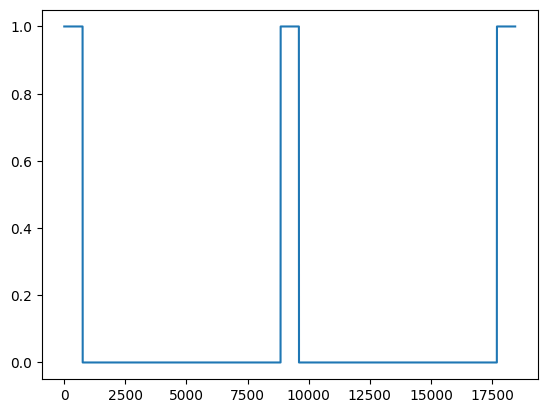

In [115]:
plt.plot(is_test_set)

print(np.sum(is_test_set) / (3 * framerate))

In [116]:
stimulus.shape

(18450, 72, 64, 3)

## Load QDSpy export stimulus sequence and trigger

In [117]:
orig_file = 'QDSpyExport/MouseCam_Right_V2-new_seq00_60Hz_10um_pixels.npz'
orig_file_mark = orig_file.replace('.npz', '_mark.npz')
orig = np.load(orig_file)
orig_mark = np.load(orig_file_mark)

setup_id = 3 if '_V1_' in orig_file else 1

setup_id

1

In [118]:
i0 = np.argmax((orig_mark['data'][:-1] > 0) & (orig_mark['data'][1:] == 0))

In [119]:
stimulus_orig = orig['data'][i0::2, 20:-20, 20:-20]  # downsample to 30 Hz
if setup_id == 3:
    stimulus_orig = np.flip(stimulus_orig, axis=-1) # flip color axis
    stimulus_orig = np.rot90(stimulus_orig, k=1, axes=(1, 2))
else:
    stimulus_orig = np.flip(np.rot90(stimulus_orig, k=1, axes=(1, 2)), axis=1)

trigger_orig = orig_mark['data'][i0::2]

# Compare to QDSpy export

v1 works  

v2: left and right were flipped in the script, probably TZ did not correct this, so they don't match

v2new works

v3 has no export yet, but since the files are as in v2new but with blobs we can compare it to that and then it looks correct


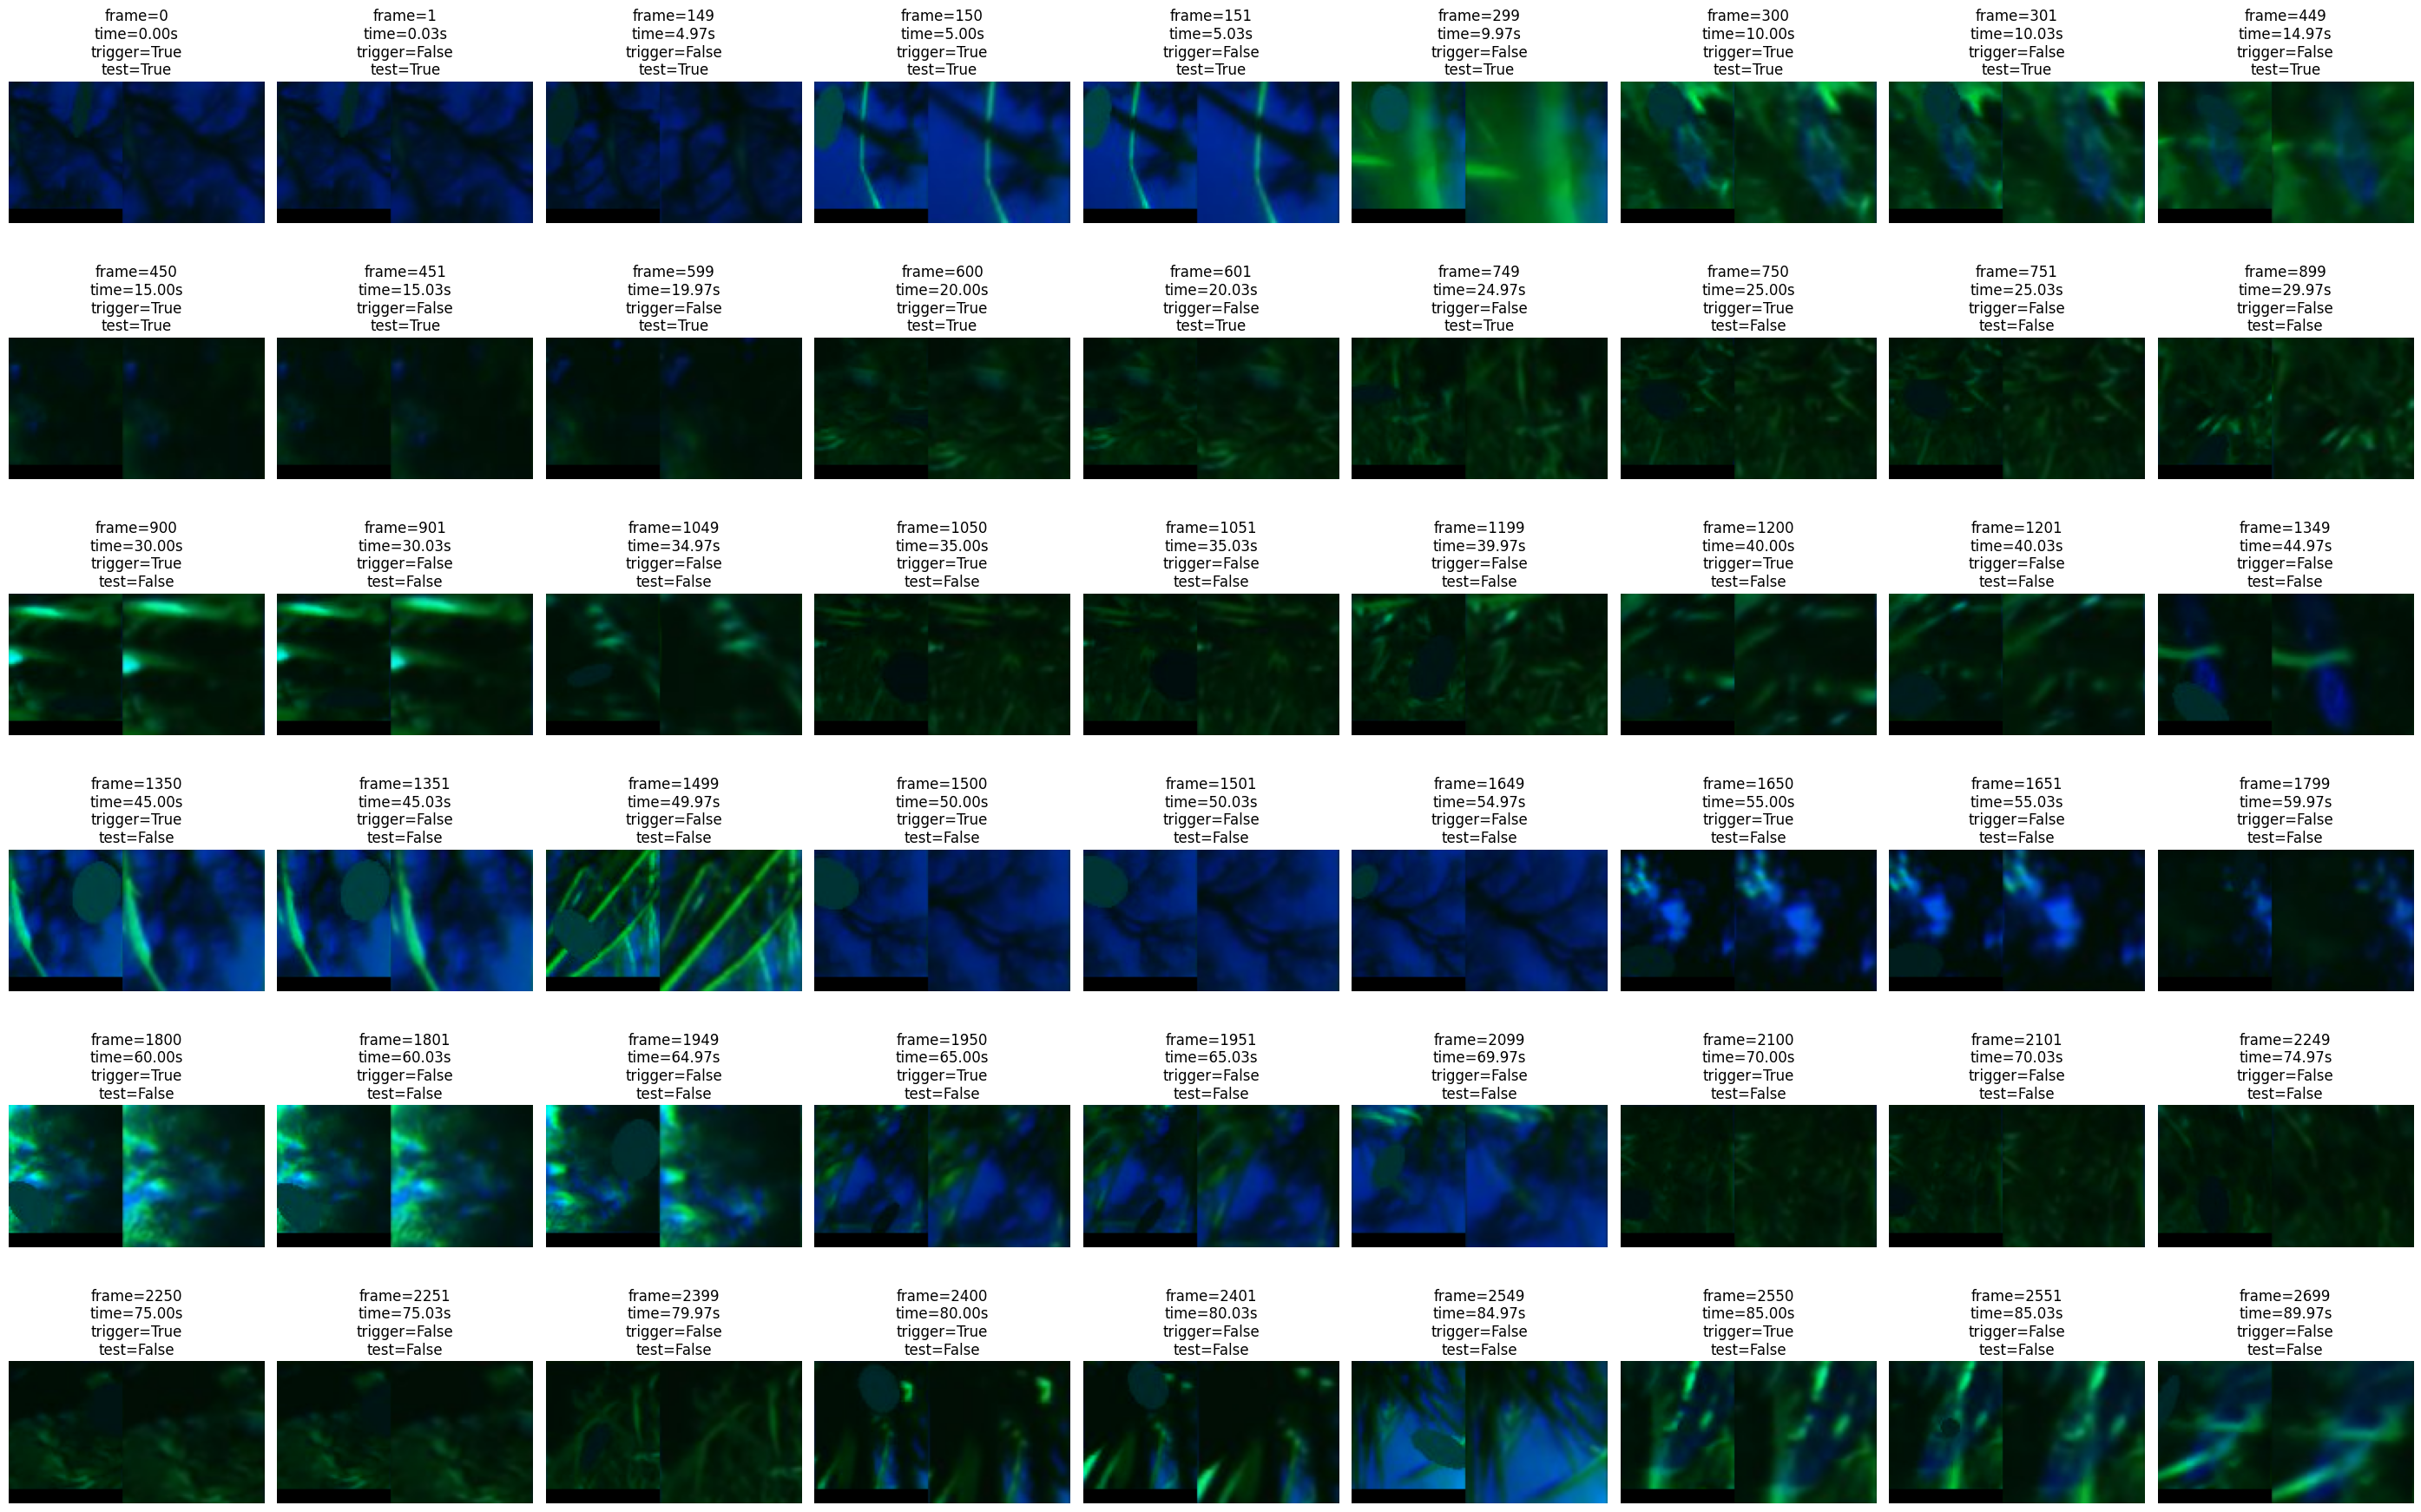

In [120]:
fig, axs = plt.subplots(6, 9, figsize=(28, 18))

frame_indices = np.sort(np.concatenate([
    np.arange(0, stimulus.shape[0], 150),
    np.arange(1, stimulus.shape[0], 150),
    np.arange(149, stimulus.shape[0], 150),
]))

for i, ax in enumerate(axs.flat):
    frame = frame_indices[i]
    a, b = stimulus[frame], stimulus_orig[frame]
    h = max(a.shape[0], b.shape[0])
    a = np.pad(a, ((0, h - a.shape[0]), (0, 0), (0, 0)))
    b = np.pad(b, ((0, h - b.shape[0]), (0, 0), (0, 0)))
    combined = np.concatenate([a, b], axis=1)
    ax.set(xticks=[], yticks=[], title=f"frame={frame}\ntime={time[frame]:.2f}s\ntrigger={trigger[frame]}\ntest={is_test_set[frame]}")
    ax.imshow(combined)
    ax.axis('off')
plt.tight_layout(h_pad=3)
